# 05 - A learning environment for local volt-var curve tuning

Notebook 04 ran the fixed volt-var controllers over the stored year 2023 on the CIGRE
European MV feeder (CIGRE TB 575, Section 6.2) with the nine PV units of Wagle et al.
(6.44 MW on feeder 1, TR1 at +4.375 %, inverter kVA = 1.1 Pmpp). Two of its findings set
the task. First, the IEEE 1547-2018 Category B default curve (B1) removes every hour above
1.05 pu, but absorbs about 1040 Mvarh in the year and raises the losses to 395.5 MWh,
whereas the per-step OPF (B5) holds the same limit with about nineteen times less
absorption and lower losses, and even the lazy fixed curve (B4) does it with 294 Mvarh.
Second, the tight curve (B3) is the wrong direction on this feeder: four times the
reactive energy for the same zero hours. The room for improvement is therefore not in the
violation hours but in the cost of removing them, and any controller that claims to do
better must be measured on the same year and the same KPIs.

This notebook defines and validates the environment in which the curve points of each
unit become adjustable. No learning takes place here; the purpose is to fix what the
agent observes, what it controls, how it is scored and what the physics guarantees, and
to show that the environment reproduces the controllers of notebook 04 exactly when
given the corresponding fixed curves. The environment is the module `env.py`; it reuses
`simulate.py` (circuit, solve, readers) and `kpi.py` (scores) unchanged.

Steps:

1. Observation, action and the family of reachable curves.
2. The reward.
3. The safety layer, with the sensitivity matrix it measures.
4. Step mechanics and timing.
5. Consistency check: the default, tight and lazy actions reproduce B1, B3 and B4.
6. Random policy on the worst day, safety layer off and on.
7. Random policy over the full year with the safety layer on.
8. Reward ranking of the fixed curves over the year.
9. Robustness of the default curve to the PV size.
10. Save `env_config.json` and `env_checks_2023.h5`.
11. Closing.

In [1]:
# Paths: this notebook runs from notebooks/, the modules live in src/ and every
# generated file in results/, so the working directory is moved there once.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(os.path.join(os.pardir, "src")))
    os.makedirs(os.path.join(os.pardir, "results"), exist_ok=True)
    os.chdir(os.path.join(os.pardir, "results"))

import json, time
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import opendssdirect as dss

import cigre_dss as cd
import simulate as sim
import kpi
import env
from env import EnvConfig, VoltVarEnv, DEFAULT_ACTION, TIGHT_ACTION, LAZY_ACTION, action_to_curve, curve_to_action

TR1_TAP = 4.375                 # % on the 20 kV side, fixed in notebook 02
assert sim.TR1_TAP_PCT == TR1_TAP and sim.KVA_RATIO == 1.1
YEAR = 2023
PV_BUSES, PV_KW, PV_KVA = sim.PV_BUSES, sim.PV_KW, sim.PV_KVA
F1 = sim.F1_BUSES               # buses 1 .. 11
DT_H = sim.DT_H
SPD = int(24 / DT_H)            # steps per day

pv, loads, attrs = sim.load_year("profiles_2023.h5")
sel = json.load(open("selected_days_2023.json"))
base = json.load(open("baselines_2023.json"))
DAY_WORST, D_WORST = sel["worst_day"], sel["worst_day_index"]
T = len(pv)
h = np.arange(0, 24, DT_H)      # solar hour within a day
w0 = D_WORST * SPD
steps_worst = np.arange(w0, w0 + SPD)
i_noon = w0 + SPD // 2

plt.rcParams.update({"font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10,
                     "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9})
def legend_below(ax, ncol=3, dy=-0.15):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, dy), ncol=ncol, frameon=False)
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

with h5py.File("baselines_2023.h5", "r") as f:
    K04 = {g: {k[4:]: float(v) for k, v in f[g].attrs.items() if k.startswith("kpi_") and not k.startswith("kpi_sample_")}
           for g in ("B0", "B1", "B3", "B4")}
runs, runtime = {}, {}          # every run of this notebook, for the save step

print("opendssdirect", dss.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)
print(f"year {attrs['year']}, {T} steps of {int(DT_H * 60)} min | worst day {DAY_WORST} (day index {D_WORST})")
print(f"TR1 tap +{TR1_TAP} %, {len(PV_BUSES)} PV units, {PV_KW.sum() / 1e3:.2f} MW, kVA = {sim.KVA_RATIO} x Pmpp "
      f"({PV_KVA.sum() / 1e3:.2f} MVA)")
print(f"notebook 04 references: B1 {K04['B1']['losses_mwh']:.1f} MWh, {K04['B1']['reactive_absorbed_mvarh']:.1f} Mvarh absorbed; "
      f"B3 {K04['B3']['reactive_absorbed_mvarh']:.1f} Mvarh; B4 {K04['B4']['reactive_absorbed_mvarh']:.1f} Mvarh")

opendssdirect 0.9.4 | pandas 2.3.3 | numpy 2.4.6
year 2023, 35040 steps of 15 min | worst day 2023-07-22 (day index 202)
TR1 tap +4.375 %, 9 PV units, 6.44 MW, kVA = 1.1 x Pmpp (7.08 MVA)
notebook 04 references: B1 395.5 MWh, 1040.4 Mvarh absorbed; B3 4272.4 Mvarh; B4 293.7 Mvarh


## 1. Observation, action and the family of reachable curves

**One step = one 15-minute step of the year.** The circuit is built once per episode
(`VoltVarEnv.build`: radial feeder 1, nine PVSystems with Pmpp = `pv_scale` times the
ratings of Wagle et al. and kVA = 1.1 Pmpp, TR1 at +4.375 %, `controlmode=static`).
Where notebook 04 used one InvControl for all nine units, every unit now has its own
XYcurve and its own InvControl (`vv<bus>`, `ic<bus>`), so that each unit can receive a
different curve.

**Local observation.** Unit $i$ sees six numbers; `obs_all()` returns the nine rows as a
(9, 6) float32 array:

| index | quantity | unit | source |
|-------|----------|------|--------|
| 0 | voltage of the unit's own bus | pu of 20 kV | previous solve |
| 1 | own active power P | pu of inverter kVA | previous solve |
| 2 | own reactive power Q (negative = absorbing) | pu of inverter kVA | previous solve |
| 3 | sin of the time of day | - | clock |
| 4 | cos of the time of day | - | clock |
| 5 | available irradiance of this step | pu of 1 kW/m2 | profile |

The voltage, P and Q are those of the previous solve, i.e. what the unit's own
measurement would show when the curve for the coming quarter hour is chosen. Nothing
about the other units or the rest of the feeder is in the local observation. A global
vector `global_obs()` (the eleven feeder-1 voltages of the previous solve) is exposed for
later use and is not part of the local observation.

**Action and curve.** The curve is the IEEE 1547-2018 Table 8 shape (Category B,
$V_\mathrm{ref}$ = 1.0 pu) with four points. The lower half is fixed, because nothing on
this feeder goes below 0.95 pu (notebook 04); the upper half is the action. The action of
one unit is $a \in [-1, 1]^3$, mapped affinely to (V3, V4, Q4) by `action_to_curve`
(`curve_to_action` is the inverse):

| point | value | status | IEEE 1547-2018 Table 8 allowable range |
|-------|-------|--------|-----------------------------------------|
| V1, Q1 | 0.92 pu, +0.44 pu of kVA | fixed | V1 in [V_ref - 0.18, V2]; Q1 in [0, 0.44] |
| V2 | 0.98 pu | fixed | [V_ref - 0.03, V_ref] |
| V3 | [1.00, 1.03] pu | action a1 | [V_ref, V_ref + 0.03] |
| V4 | [V3 + 0.02, 1.18] pu | action a2 | [V3, V_ref + 0.18] |
| Q4 | [0, 0.44] pu of kVA | action a3 | [0, 0.44] |

V3 is where absorption starts, V4 where it reaches its clamp and Q4 how deep the clamp
is. Because V4 is parameterised relative to V3, V1 < V2 < V3 < V4 holds for every action
and no action can produce an invalid curve; every reachable curve is inside the allowable
ranges of the standard. `DEFAULT_ACTION` gives the Category B default (V3 = 1.02,
V4 = 1.08, Q4 = 0.44) of B1, `TIGHT_ACTION` the curve of B3 (1.00, 1.04, 0.44) and
`LAZY_ACTION` the curve of B4 (1.03, 1.10, 0.44).

The figure shows (a) twenty actions drawn uniformly from $[-1, 1]^3$ over the default
curve, with the 1.05 pu limit and the V3 range shaded, and (b) the default, tight and
lazy curves.

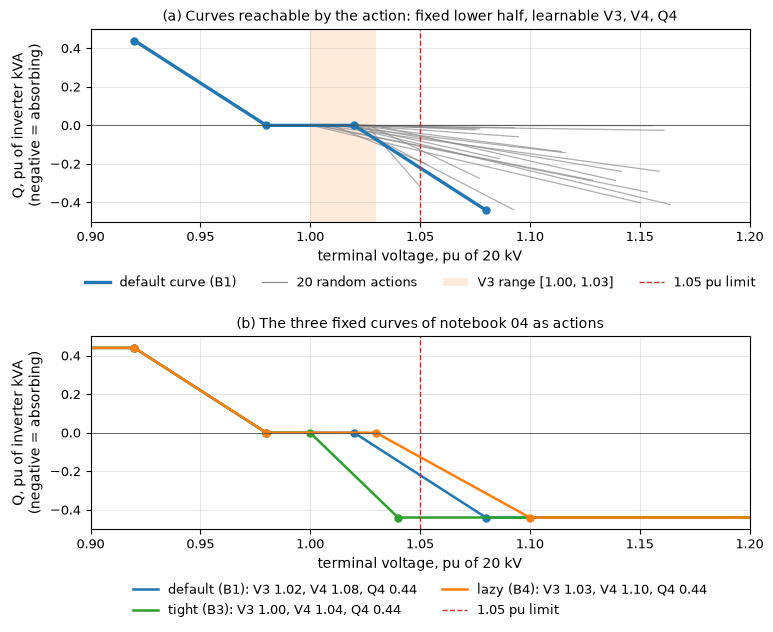

curves of the 20 random actions: V3 in [1.000, 1.029], V4 in [1.050, 1.164], Q4 in [0.001, 0.439]; mean V3 1.016, V4 1.114, Q4 0.201
inverse mapping check: max |curve_to_action(action_to_curve(a)) - a| = 3.6e-15
  default (B1)   action [ 0.3333 -0.4286  1.    ] -> curve (V3, V4, Q4) = [1.02 1.08 0.44]
  tight (B3)     action [-1.   -0.75  1.  ] -> curve (V3, V4, Q4) = [1.   1.04 0.44]
  lazy (B4)      action [ 1.     -0.2308  1.    ] -> curve (V3, V4, Q4) = [1.03 1.1  0.44]


In [2]:
rng = np.random.default_rng(0)
A = rng.uniform(-1, 1, size=(20, 3)); C = action_to_curve(A)
vgrid = np.linspace(0.90, 1.20, 601)
FIXED = {"default (B1): V3 1.02, V4 1.08, Q4 0.44": (DEFAULT_ACTION, "tab:blue"),
         "tight (B3): V3 1.00, V4 1.04, Q4 0.44": (TIGHT_ACTION, "tab:green"),
         "lazy (B4): V3 1.03, V4 1.10, Q4 0.44": (LAZY_ACTION, "tab:orange")}

fig, axes = plt.subplots(2, 1, figsize=(8, 6.5))
ax = axes[0]
for (v3, v4, q4) in C:
    x, y = env.curve_xy(v3, v4, q4)
    ax.plot(x, y, color="0.55", lw=0.9, alpha=0.7)
x, y = env.curve_xy(*action_to_curve(DEFAULT_ACTION))
ax.plot(x, y, color="tab:blue", lw=2.4, label="default curve (B1)")
ax.plot(x, y, "o", color="tab:blue", ms=5)
ax.plot([], [], color="0.55", lw=0.9, label="20 random actions")
ax.axvspan(*env.V3_RANGE, color="tab:orange", alpha=0.15, lw=0, label="V3 range [1.00, 1.03]")
ax.axvline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu limit")
ax.axhline(0, color="0.3", lw=0.6)
ax.set_xlim(0.90, 1.20); ax.set_ylim(-0.5, 0.5); ax.grid(alpha=0.3)
ax.set_xlabel("terminal voltage, pu of 20 kV"); ax.set_ylabel("Q, pu of inverter kVA\n(negative = absorbing)")
ax.set_title("(a) Curves reachable by the action: fixed lower half, learnable V3, V4, Q4")
legend_below(ax, ncol=4, dy=-0.22)
ax = axes[1]
for lab, (a, col) in FIXED.items():
    x, y = env.curve_xy(*action_to_curve(a))
    ax.plot(vgrid, np.interp(vgrid, x, y), color=col, lw=1.8, label=lab)
    ax.plot(x, y, "o", color=col, ms=5)
ax.axvline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu limit")
ax.axhline(0, color="0.3", lw=0.6)
ax.set_xlim(0.90, 1.20); ax.set_ylim(-0.5, 0.5); ax.grid(alpha=0.3)
ax.set_xlabel("terminal voltage, pu of 20 kV"); ax.set_ylabel("Q, pu of inverter kVA\n(negative = absorbing)")
ax.set_title("(b) The three fixed curves of notebook 04 as actions")
legend_below(ax, ncol=2, dy=-0.22)
plt.tight_layout(); plt.show()

print("curves of the 20 random actions: V3 in [%.3f, %.3f], V4 in [%.3f, %.3f], Q4 in [%.3f, %.3f]; "
      "mean V3 %.3f, V4 %.3f, Q4 %.3f" % (C[:, 0].min(), C[:, 0].max(), C[:, 1].min(), C[:, 1].max(),
                                          C[:, 2].min(), C[:, 2].max(), C[:, 0].mean(), C[:, 1].mean(), C[:, 2].mean()))
a_test = np.array([0.3, -0.7, 0.1])
a_back = curve_to_action(*action_to_curve(a_test))
print(f"inverse mapping check: max |curve_to_action(action_to_curve(a)) - a| = {np.abs(a_back - a_test).max():.1e}")
for lab, (a, _) in FIXED.items():
    print(f"  {lab.split(':')[0]:14s} action {np.array2string(a, precision=4)} -> curve (V3, V4, Q4) = {np.array2string(action_to_curve(a), precision=3)}")

Every curve of the family is a valid Category B curve. A uniformly random action has, on
average, V3 near 1.015, V4 near 1.10 and Q4 near 0.22 pu, i.e. a weaker but earlier-acting
version of the default; the corners of the family are the do-nothing curve (Q4 = 0) and the
curve that clamps -0.44 pu already at 1.02 pu (V3 = 1.00, V4 = 1.02).

## 2. The reward

One scalar per step, shared by all nine units (so no joint action space is needed and
every unit is credited with the same outcome):

$$
r = \underbrace{-\,w_\mathrm{viol} \sum_{b=1}^{11} \max(0,\;V_b - 1.05,\;0.95 - V_b)
    \;-\; w_\mathrm{loss}\, P_\mathrm{loss}
    \;-\; w_q \sum_{i=1}^{9} |Q_i|
    \;-\; w_\mathrm{curt}\, P_\mathrm{curt}}_{\text{core reward}}
    \;-\; w_\mathrm{safety}\,(\Delta Q_\mathrm{fence} + 10\,\Delta P_\mathrm{fence})
    \;-\; w_\mathrm{event}\,[\text{fence acted}]
$$

| term | quantity | unit | weight | why it is there |
|------|----------|------|--------|-----------------|
| voltage excess | sum over buses 1 to 11 of the distance outside the band, after the fence | pu | $w_\mathrm{viol}$ = 1000 per pu | the constraint: the per-step VPI of `kpi.py` without the $\Delta t$, with the same 1000 that the OPF of notebook 04 used per violated bus |
| losses | total circuit losses | kW | $w_\mathrm{loss}$ = 0.01 per kW | the efficiency objective; 1 kW of losses costs as much as 10 kvar |
| reactive power | sum of the absolute reactive power of the nine units | kvar | $w_q$ = 0.001 per kvar | the effort objective: reactive power that buys nothing should not be spent; it is what separates B1 from B4 |
| curtailment | sum over units of max(0, Pmpp x irradiance - P) | kW | $w_\mathrm{curt}$ = 0.05 per kW | energy not delivered; five times the loss weight, so that curtailment is the last resort |
| fence charge | kvar the safety layer added plus ten times the kW it curtailed | kvar, kW | $w_\mathrm{safety}$ = 0.002 | the correction is the agent's fault: what the fence spends is charged twice as dearly as what the curve spends |
| fence event | 1 on a step on which the safety layer acted | - | $w_\mathrm{event}$ = 5 | a fixed price per intervention, larger than any ordinary step, so that needing the fence is never a good trade |

The first four terms are the **core reward** (`info["reward_core"]`, `env.reward_core_of`),
the value that fixed curves are compared on: the fence never acts on a curve that holds
the limit, so for such a curve the total and the core reward coincide. The last two terms
only exist when the safety layer intervenes. At the magnitudes of this feeder (losses
about 45 kW, reactive power about 120 kvar on average, excess a few thousandths of a pu on
a violated step) the loss, reactive and violation terms are of the order 0.5, 0.1 and
several units per step, so a violation dominates the step on which it happens, while the
loss and reactive terms decide between curves that hold the limit. The weights live in
`EnvConfig` together with `pv_scale`, `kva_ratio`, `tr1_tap_pct`, `safety_layer`, `year`
and `seed`; the cell prints the configuration used throughout.

In [3]:
CFG = EnvConfig()
print("EnvConfig defaults of this study:")
for k, v in CFG.__dict__.items():
    print(f"  {k:18s} {v}")
WEIGHTS = {"w_viol": "per pu of voltage excess", "w_loss": "per kW of losses", "w_q": "per kvar of |Q|",
           "w_curt": "per kW curtailed", "w_safety": "per kvar added by the fence (and per 0.1 kW it curtails)",
           "w_safety_event": "per step on which the fence acts"}
print("\nreward weights:")
for k, meaning in WEIGHTS.items():
    print(f"  {k:16s} {getattr(CFG, k):8g}   {meaning}")

EnvConfig defaults of this study:
  pv_scale           1.0
  kva_ratio          1.1
  tr1_tap_pct        4.375
  safety_layer       True
  year               2023
  seed               0
  w_viol             1000.0
  w_loss             0.01
  w_q                0.001
  w_curt             0.05
  w_safety           0.002
  w_safety_event     5.0
  v_hi               1.05
  v_lo               0.95
  safety_margin      0.002
  safety_q_cap_pu    None
  profiles           profiles_2023.h5
  label              

reward weights:
  w_viol               1000   per pu of voltage excess
  w_loss               0.01   per kW of losses
  w_q                 0.001   per kvar of |Q|
  w_curt               0.05   per kW curtailed
  w_safety            0.002   per kvar added by the fence (and per 0.1 kW it curtails)
  w_safety_event          5   per step on which the fence acts


## 3. The safety layer

The agent proposes, the physics vetoes. With `EnvConfig.safety_layer = True`, after the
solve of a step the environment checks the eleven feeder-1 voltages; if any is above
1.05 pu or below 0.95 pu, the InvControls are switched off and the current Q of every
unit is frozen, so that the circuit becomes a plain power flow. The sensitivity matrix
$S = \partial V_\mathrm{bus} / \partial Q_\mathrm{unit}$ (11 x 9, pu per kvar) is then
measured by finite differences at the current operating point: nine extra solves, each
with one unit absorbing an additional 1 % of its kVA. The smallest additional absorption
$\Delta Q \ge 0$ per unit that brings every violated bus to 1.05 - 0.002 pu (the margin
keeps the corrected bus clear of the limit after the re-solve) is found by bounded least
squares on the violated rows of $S$ (`scipy.optimize.lsq_linear`, method BVLS), bounded
per unit by the remaining capability $\sqrt{\mathrm{kVA}^2 - P^2} - |Q|$, applied as fixed
kvar setpoints, and the step is re-solved. One refinement with the same $S$ follows if a
violation remains. If the reactive capability is exhausted and a violation still remains,
active power is curtailed as a last resort in the same way, with $\partial V / \partial P$
measured by nine more solves, by lowering the irradiance of the affected units. The step
reports `info["safety_active"]`, `info["safety_dq"]` (kvar added, summed over units),
`info["safety_dp"]` (kW curtailed) and the number of solves it used, and the reward is
computed from the post-fence state, with the fence charge of step 2 on top. Because the
sensitivities are measured on the actual circuit at the actual operating point, the fence
uses the same information as the OPF of notebook 04, once per violated step instead of in
a full optimisation.

The figure shows $S$ as the fence would measure it at the operating point of the
worst-day noon step (2023-07-22 12:00) under the default curve: rows are the feeder-1
buses, columns the nine units, the colour is the voltage drop at the bus per Mvar
absorbed by the unit, in thousandths of a pu.

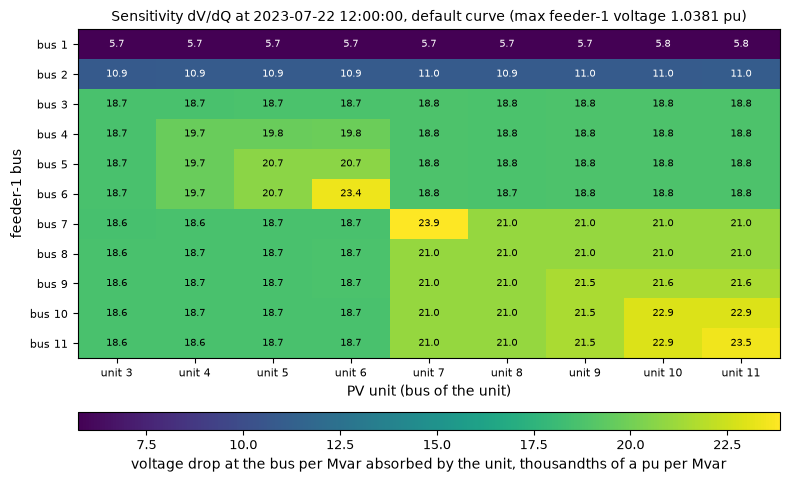

voltage drop at bus 11 per Mvar absorbed: unit 11 23.5, unit 3 18.6 mpu/Mvar (1.3 times); at bus 1 (TR1 secondary): unit 11 5.8, unit 3 5.7 mpu/Mvar
the three units that move bus 11 the most: [11, 10, 9]; the largest entry of S is 23.9 mpu/Mvar (bus 7, unit 7)


In [4]:
E = VoltVarEnv(EnvConfig(safety_layer=False), pv, loads)
E.reset(steps=[i_noon])
_, _, _, info_noon = E.step(np.tile(DEFAULT_ACTION, (9, 1)))
S = E.sensitivity("q")                     # 11 x 9, pu per kvar; positive = absorption lowers the voltage
S_m = S * 1e6                              # milli-pu per Mvar absorbed, for readability

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(S_m, cmap="viridis", aspect="auto")
ax.set_xticks(range(9)); ax.set_xticklabels([f"unit {b}" for b in PV_BUSES], fontsize=8)
ax.set_yticks(range(11)); ax.set_yticklabels([f"bus {b}" for b in F1], fontsize=8)
for r_ in range(11):
    for c_ in range(9):
        ax.text(c_, r_, f"{S_m[r_, c_]:.1f}", ha="center", va="center", fontsize=7,
                color="white" if S_m[r_, c_] < 0.6 * S_m.max() else "black")
cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.12, aspect=40)
cb.set_label("voltage drop at the bus per Mvar absorbed by the unit, thousandths of a pu per Mvar")
ax.set_xlabel("PV unit (bus of the unit)"); ax.set_ylabel("feeder-1 bus")
ax.set_title(f"Sensitivity dV/dQ at {pv.index[i_noon]}, default curve (max feeder-1 voltage {info_noon['v'].max():.4f} pu)")
plt.tight_layout(); plt.show()

j11, j1 = F1.index(11), F1.index(1)
u11, u3 = PV_BUSES.index(11), PV_BUSES.index(3)
print(f"voltage drop at bus 11 per Mvar absorbed: unit 11 {S_m[j11, u11]:.1f}, unit 3 {S_m[j11, u3]:.1f} mpu/Mvar "
      f"({S_m[j11, u11] / S_m[j11, u3]:.1f} times); at bus 1 (TR1 secondary): unit 11 {S_m[j1, u11]:.1f}, unit 3 {S_m[j1, u3]:.1f} mpu/Mvar")
far = [PV_BUSES[j] for j in np.argsort(-S_m[j11])[:3]]
print(f"the three units that move bus 11 the most: {far}; the largest entry of S is {S_m.max():.1f} mpu/Mvar "
      f"(bus {F1[np.unravel_index(S_m.argmax(), S_m.shape)[0]]}, unit {PV_BUSES[np.unravel_index(S_m.argmax(), S_m.shape)[1]]})")

The matrix has the structure of the radial feeder. Every unit lowers buses 1 and 2 (the
TR1 secondary and the first segment) by the same small amount, because that part of the
path is shared; from bus 3 onwards the two branches of feeder 1 appear as two diagonal
blocks, and within each block a kvar absorbed at a far-end unit lowers the far-end
voltages the most (unit 11 moves bus 11 by 23.5 thousandths of a pu per Mvar, unit 3 by
18.6). The contrast between the far end and the head of the feeder is only about 1.3 to
1, because most of the impedance between a unit and the 110 kV grid is common to all of
them; this is also why the local curve of notebook 04 asked every unit for nearly the same
Q. The fence exploits the remaining contrast: on a violated step it puts the additional
absorption where a kvar moves the violated bus most, which is where the OPF of notebook
04 placed it, at the far ends of the feeder.

## 4. Step mechanics and timing

Per step, `step(actions)` (i) writes the nine curves in place through the XYCurves API,
(ii) scales the two load sectors and sets the nine irradiances to their profile values,
(iii) solves the snapshot, with OpenDSS iterating the control loop to the fixed point of
curves and network inside the solve (as in `simulate.run_year`), (iv) runs the safety
layer if a bus is outside the band, (v) computes the reward and its terms from the final
state, and (vi) returns the nine observations for the next step. `reset(day=...)`,
`reset(steps=...)` or `reset()` (whole year) starts an episode: the circuit is rebuilt and
the step before the first one is solved with the default curve, so that the first
observation carries a sensible previous state. `run_policy(policy_fn, steps)` runs an
episode and returns an `EnvYearResult`, on which `kpi.kpis_of` works unchanged and whose
`.extra` holds the reward, its terms, the safety statistics and the curves applied.

The cell times the two operations that matter for training: a reset, and a step with the
control loop (one solve plus eighteen array writes, plus the fence solves on an intervened
step).

In [5]:
E = VoltVarEnv(EnvConfig(safety_layer=True), pv, loads)
t0 = time.perf_counter(); obs0 = E.reset(steps=steps_worst); t_reset = time.perf_counter() - t0
n0 = E.n_solves; t0 = time.perf_counter()
for k in range(SPD):
    obs, r, done, info = E.step(np.tile(DEFAULT_ACTION, (9, 1)))
t_step = (time.perf_counter() - t0) / SPD
print(f"reset (circuit build + one solve): {t_reset * 1e3:.1f} ms")
print(f"step with the default curve on the worst day, fence on: {t_step * 1e3:.2f} ms per step, "
      f"{(E.n_solves - n0) / SPD:.2f} solves per step (fence acted on none)")
print(f"observation shape {obs.shape} {obs.dtype}, global vector {E.global_obs().shape}; last step done = {done}")
print("observation of unit 11 at the end of the day:", {n: f"{x:.3f}" for n, x in zip(env.OBS_NAMES, obs[PV_BUSES.index(11)])})
print("reward terms of the last step:", {k: f"{v:.3f}" for k, v in info["terms"].items()})

reset (circuit build + one solve): 8.5 ms
step with the default curve on the worst day, fence on: 0.65 ms per step, 1.00 solves per step (fence acted on none)
observation shape (9, 6) float32, global vector (11,); last step done = True
observation of unit 11 at the end of the day: {'v_pu': '1.024', 'p_pu_kva': '0.000', 'q_pu_kva': '-0.028', 'sin_tod': '-0.065', 'cos_tod': '0.998', 'irr_pu': '0.000'}
reward terms of the last step: {'viol': '-0.000', 'loss': '-0.104', 'q': '-0.231', 'curt': '-0.000', 'safety': '-0.000'}


## 5. Consistency check: the fixed actions reproduce B1, B3 and B4

The environment is run over the full year three times with the safety layer off, with the
constant `DEFAULT_ACTION`, `TIGHT_ACTION` and `LAZY_ACTION` on every unit. Nine per-unit
InvControls instead of one, curves written through the API at every step, the reward
machinery and the step bookkeeping must not change the physics: the KPIs have to match
B1, B3 and B4 of `baselines_2023.h5` to within 0.1 % (violation hours 0, losses 395.5 MWh
and 1040.4 Mvarh absorbed for B1). These three runs are also the fixed-curve references
of step 8.

In [6]:
FIXED_ACTIONS = {"default": (DEFAULT_ACTION, "B1"), "tight": (TIGHT_ACTION, "B3"), "lazy": (LAZY_ACTION, "B4")}
for name, (a, ref) in FIXED_ACTIONS.items():
    r = VoltVarEnv(EnvConfig(safety_layer=False), pv, loads).run_policy(env.constant_policy(a), None, label=f"{name} action, fence off")
    runs[f"{name}_off"] = r; runtime[f"{name}_off"] = r.runtime_s
with h5py.File("baselines_2023.h5", "r") as f:
    v_B1 = f["B1/v"][:]; q_B1 = f["B1/q_kvar"][:]

CHECK = ("hours_violation", "vpi", "losses_mwh", "reactive_absorbed_mvarh", "reactive_injected_mvarh", "curtailed_mwh", "vmax", "vmin")
for name, (a, ref) in FIXED_ACTIONS.items():
    k_env, k_ref = kpi.kpis_of(runs[f"{name}_off"]), K04[ref]
    print(f"\n{name} action against {ref} of notebook 04")
    print(f"  {'KPI':32s} {'environment':>14s} {ref + ' (nb 04)':>14s} {'rel. diff':>10s}")
    for c in CHECK:
        rel = abs(k_env[c] - k_ref[c]) / k_ref[c] if k_ref[c] > 1e-3 else abs(k_env[c] - k_ref[c])
        print(f"  {kpi.KPI_LABELS[c]:32s} {k_env[c]:14.4f} {k_ref[c]:14.4f} {rel:10.2e}")
    assert k_env["hours_violation"] == 0.0 and k_ref["hours_violation"] == 0.0
    assert abs(k_env["losses_mwh"] / k_ref["losses_mwh"] - 1) < 1e-3
    assert abs(k_env["reactive_absorbed_mvarh"] / k_ref["reactive_absorbed_mvarh"] - 1) < 1e-3
r1 = runs["default_off"]
print(f"\nper-step, default action against B1: max |V - V_B1| = {np.abs(r1.v - v_B1).max():.2e} pu, max |Q - Q_B1| = {np.abs(r1.q_kvar - q_B1).max():.2f} kvar")
print("consistency check passed: violation hours 0, losses and absorbed reactive energy within 0.1 % of B1, B3 and B4")

default action, fence off         : 35040 steps in   20.7 s (0.59 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


tight action, fence off           : 35040 steps in   22.8 s (0.65 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


lazy action, fence off            : 35040 steps in   19.3 s (0.55 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0

default action against B1 of notebook 04
  KPI                                 environment     B1 (nb 04)  rel. diff
  hours outside 0.95-1.05 pu               0.0000         0.0000   0.00e+00
  VPI, pu.h                                0.0000         0.0000   0.00e+00
  losses, MWh                            395.5189       395.5191   2.63e-07
  reactive energy absorbed, Mvarh       1040.3900      1040.3992   8.85e-06
  reactive energy injected, Mvarh         41.1247        41.1242   1.26e-05
  curtailed PV, MWh                        0.0000         0.0000   4.90e-08
  max voltage, pu                          1.0421         1.0421   0.00e+00
  min voltage, pu                          0.9707         0.9707   3.43e-16

tight action against B3 of notebook 04
  KPI                                 environment     B3 (nb 04)  rel. diff
  hours outsid

The environment reproduces the three fixed controllers to well within the required 0.1 %
(the residual is the control-iteration tolerance, below 0.1 mpu and 1 kvar per step).
Anything the following steps show that differs from notebook 04 is therefore caused by
the actions or by the safety layer, not by the loop, and the baselines of notebook 04
remain valid references.

## 6. Random policy on the worst day, safety layer off and on

A policy that draws a fresh uniform action for every unit at every step is run over the
96 steps of the worst day (2023-07-22), once with the safety layer off and once with it
on, with the same seed so that both runs see exactly the same sequence of actions. The
figure shows (a) the voltage of bus 11 (the far end of feeder 1) for both runs, with the
steps on which the fence intervened shaded; (b) the total reactive power of the nine
units for both runs; (c) the per-step core reward of both runs. The table gives the count
of interventions, how much reactive and active power the fence added, the violation hours
and the core reward of the day.

random, worst day, fence off      : 96 steps in    0.1 s (0.63 ms per step), safety active on 0 steps, 96 solves, control-loop failures 0


random, worst day, fence on       : 96 steps in    0.1 s (0.80 ms per step), safety active on 2 steps, 118 solves, control-loop failures 0


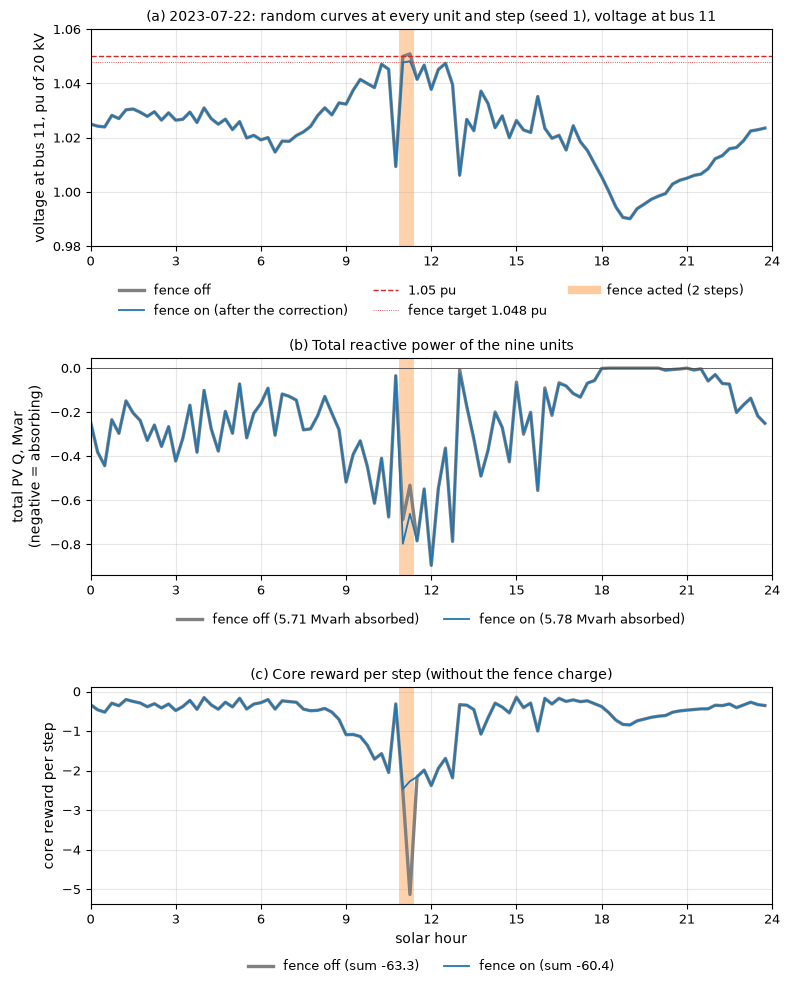

           steps  fence_steps  curtail_steps  dq_kvarh  dq_max_kvar  dp_kwh  dp_max_kw  solves_per_intervention  hours_violation  vmax  vmax_before  q_abs_mvarh  reward_core  reward_total
fence off     96            0              0         0            0       0          0                        0              0.5 1.051        1.051         5.71       -63.33        -63.33
fence on      96            2              0     59.85        129.4       0          0                       11                0 1.048        1.051        5.775       -60.42         -70.9


In [7]:
r_off = VoltVarEnv(EnvConfig(safety_layer=False, seed=1), pv, loads).run_policy(env.random_policy, steps_worst, label="random, worst day, fence off")
r_on = VoltVarEnv(EnvConfig(safety_layer=True, seed=1), pv, loads).run_policy(env.random_policy, steps_worst, label="random, worst day, fence on")
runs["random_worst_off"] = r_off; runs["random_worst_on"] = r_on
assert np.allclose(r_off.extra["curves"], r_on.extra["curves"])       # same actions in both runs
act = r_on.extra["safety_active"]; j11 = F1.index(11)

fig, axes = plt.subplots(3, 1, figsize=(8, 10))
for ax in axes:
    for k in np.where(act)[0]:
        ax.axvspan(h[k] - DT_H / 2, h[k] + DT_H / 2, color="tab:orange", alpha=0.35, lw=0)
ax = axes[0]
ax.plot(h, r_off.v[:, j11], color="0.5", lw=2.4, label="fence off")
ax.plot(h, r_on.v[:, j11], color="tab:blue", lw=1.3, label="fence on (after the correction)")
ax.axhline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu")
ax.axhline(1.05 - 0.002, color="tab:red", lw=0.6, ls=":", label="fence target 1.048 pu")
ax.plot([], [], color="tab:orange", lw=6, alpha=0.4, label=f"fence acted ({int(act.sum())} steps)")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0.98, 1.06); ax.grid(alpha=0.3)
ax.set_ylabel("voltage at bus 11, pu of 20 kV")
ax.set_title(f"(a) {DAY_WORST}: random curves at every unit and step (seed 1), voltage at bus 11")
legend_below(ax, ncol=3, dy=-0.12)
ax = axes[1]
ax.plot(h, r_off.q_kvar.sum(axis=1) / 1e3, color="0.5", lw=2.4, label=f"fence off ({-np.minimum(r_off.q_kvar, 0).sum() * DT_H / 1e3:.2f} Mvarh absorbed)")
ax.plot(h, r_on.q_kvar.sum(axis=1) / 1e3, color="tab:blue", lw=1.3, label=f"fence on ({-np.minimum(r_on.q_kvar, 0).sum() * DT_H / 1e3:.2f} Mvarh absorbed)")
ax.axhline(0, color="0.3", lw=0.6)
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.grid(alpha=0.3)
ax.set_ylabel("total PV Q, Mvar\n(negative = absorbing)"); ax.set_title("(b) Total reactive power of the nine units")
legend_below(ax, ncol=2, dy=-0.12)
ax = axes[2]
ax.plot(h, r_off.extra["reward_core"], color="0.5", lw=2.4, label=f"fence off (sum {r_off.extra['reward_core'].sum():.1f})")
ax.plot(h, r_on.extra["reward_core"], color="tab:blue", lw=1.3, label=f"fence on (sum {r_on.extra['reward_core'].sum():.1f})")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.grid(alpha=0.3)
ax.set_xlabel("solar hour"); ax.set_ylabel("core reward per step"); ax.set_title("(c) Core reward per step (without the fence charge)")
legend_below(ax, ncol=2, dy=-0.2)
plt.tight_layout(); plt.show()

def safety_stats(r):
    e = r.extra; k = kpi.kpis_of(r); a = e["safety_active"]
    return dict(steps=len(a), fence_steps=int(a.sum()), curtail_steps=int((e["safety_dp"] > 0).sum()),
                dq_kvarh=float(e["safety_dq"].sum() * DT_H), dq_max_kvar=float(e["safety_dq"].max()),
                dp_kwh=float(e["safety_dp"].sum() * DT_H), dp_max_kw=float(e["safety_dp"].max()),
                solves_per_intervention=float(e["safety_solves"][a].mean()) if a.any() else 0.0,
                hours_violation=k["hours_violation"], vmax=k["vmax"], vmax_before=float(e["v_before"].max()),
                q_abs_mvarh=k["reactive_absorbed_mvarh"], reward_core=float(e["reward_core"].sum()),
                reward_total=float(e["reward"].sum()))
tab6 = pd.DataFrame({"fence off": safety_stats(r_off), "fence on": safety_stats(r_on)}).T
print(tab6.to_string(float_format=lambda x: f"{x:.4g}"))

The random policy keeps bus 11 inside the band for most of the day even without the
fence, because a random action is a weaker but still absorbing curve; the excursions above
1.05 pu occur at midday when a weak draw coincides with full output. On those steps the
fence adds the least-squares absorption and brings the highest bus to 1.048 pu, the target
1.05 minus the margin, at a cost of about ten extra plain solves per intervention. The
core-reward traces coincide except on the intervened steps, where the fenced run loses the
violation term and pays a little more in reactive power instead; the total reward of the
fenced run is lower than its core reward by the fence charge of those steps. No
curtailment was needed: the remaining reactive capability of the nine units is far larger
than what the correction requires at this PV size.

## 7. Random policy over the full year with the safety layer on

The same random policy over all 35,040 steps, safety layer on, seed 0. The KPIs are
compared with B0 and B1 of notebook 04. The figure shows (a) the distribution of the
per-step core reward, night and daylight steps separately, and (b) the number of fence
interventions per month. This run also gives the runtime of a full year in the environment
with the fence active.

random, full year, fence on       : 35040 steps in   22.1 s (0.63 ms per step), safety active on 13 steps, 35183 solves, control-loop failures 0
                         h_outside        VPI_puh loss_MWh curt_MWh Qabs_Mvarh Qinj_Mvarh     fail       Vmax       Vmin
B0 unity pf (nb 04)               199.75     3.9947     383.74         0.000                    0.00                    0.00          0     1.0637     0.9620
B1 default curve (nb 04)            0.00     0.0000     395.52         0.000                 1040.40                   41.12          0     1.0421     0.9707
random policy + fence               0.00     0.0000     393.69         0.017                 1016.08                   41.13          0     1.0500     0.9706

fence: active on 13 of 35040 steps, 466 kvarh added, 0.0 kWh curtailed, max voltage before the fence 1.0527 pu, after 1.0500 pu; runtime 22.1 s (0.63 ms per step)
reward over the year: core -19980, fence charge -68.7, total -20049


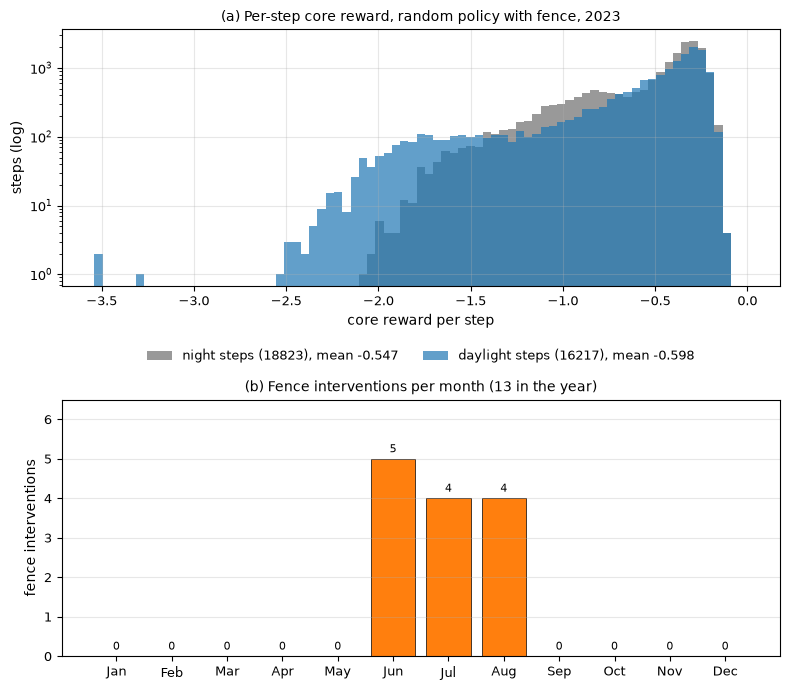

worst step (core reward -3.54) at 2023-07-22 11:00:00


In [8]:
r_ry = VoltVarEnv(EnvConfig(safety_layer=True, seed=0), pv, loads).run_policy(env.random_policy, None, label="random, full year, fence on")
runs["random_year_on"] = r_ry; runtime["random_year_on"] = r_ry.runtime_s
k_ry = kpi.kpis_of(r_ry)
COLS = ["hours_violation", "vpi", "losses_mwh", "curtailed_mwh", "reactive_absorbed_mvarh", "reactive_injected_mvarh", "n_fail", "vmax", "vmin"]
def show(kp):
    print(kpi.format_table(kpi.kpi_table(kp, COLS)).replace("hours_violation", "h_outside").replace("vpi", "VPI_puh")
          .replace("losses_mwh", "loss_MWh").replace("curtailed_mwh", "curt_MWh").replace("reactive_absorbed_mvarh", "Qabs_Mvarh")
          .replace("reactive_injected_mvarh", "Qinj_Mvarh").replace("n_fail", "fail").replace("vmax", "Vmax").replace("vmin", "Vmin"))
show({"B0 unity pf (nb 04)": K04["B0"], "B1 default curve (nb 04)": K04["B1"], "random policy + fence": k_ry})
st7 = safety_stats(r_ry)
print(f"\nfence: active on {st7['fence_steps']} of {st7['steps']} steps, {st7['dq_kvarh']:.0f} kvarh added, "
      f"{st7['dp_kwh']:.1f} kWh curtailed, max voltage before the fence {st7['vmax_before']:.4f} pu, after {st7['vmax']:.4f} pu; "
      f"runtime {r_ry.runtime_s:.1f} s ({r_ry.runtime_s / T * 1e3:.2f} ms per step)")
print(f"reward over the year: core {st7['reward_core']:.0f}, fence charge {r_ry.extra['term_safety'].sum():.1f}, total {st7['reward_total']:.0f}")

e = r_ry.extra; daylight = r_ry.irr.max(axis=1) > 0
per_month = pd.Series(e["safety_active"].astype(int), index=r_ry.index).resample("MS").sum()
fig, axes = plt.subplots(2, 1, figsize=(8, 7))
ax = axes[0]
bins = np.linspace(e["reward_core"].min(), 0, 80)
ax.hist(e["reward_core"][~daylight], bins=bins, color="0.6", label=f"night steps ({(~daylight).sum()}), mean {e['reward_core'][~daylight].mean():.3f}")
ax.hist(e["reward_core"][daylight], bins=bins, color="tab:blue", alpha=0.7, label=f"daylight steps ({daylight.sum()}), mean {e['reward_core'][daylight].mean():.3f}")
ax.set_yscale("log"); ax.set_xlabel("core reward per step"); ax.set_ylabel("steps (log)"); ax.grid(alpha=0.3)
ax.set_title(f"(a) Per-step core reward, random policy with fence, {YEAR}")
legend_below(ax, ncol=2, dy=-0.2)
ax = axes[1]
ax.bar(range(12), per_month.values, color="tab:orange", edgecolor="black", lw=0.5)
for m, n_ in enumerate(per_month.values):
    ax.text(m, n_ + 0.1, str(int(n_)), ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS); ax.set_ylabel("fence interventions"); ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(per_month.max() * 1.3, 1))
ax.set_title(f"(b) Fence interventions per month ({int(per_month.sum())} in the year)")
plt.tight_layout(); plt.show()
print("worst step (core reward %.2f) at %s" % (e["reward_core"].min(), r_ry.index[int(np.argmin(e["reward_core"]))]))

Even a random curve at every unit and step, fenced, leaves no violation hour and is close
to B1 in losses and reactive energy: the average random curve is a milder default. The
fence acted on a few tens of steps, all in the sunny months, and added a fraction of a
Mvarh. The core reward is concentrated between -0.2 and -1 per step for night and day
alike (at night only the losses of the load flow and the injection of the fixed lower half
of the curve at the lightly loaded hours remain), with a daylight tail down to about -3.5
on the sunny midday steps, where the loss and reactive terms are largest. The full year
costs about twenty seconds, which is what one pass of a training epoch costs.

## 8. Reward ranking of the fixed curves over the year

The three full-year runs of step 5 (default, tight and lazy action at every unit, fence
off) are scored by the core reward and its four terms. The expectation from notebook 04
is that the default beats the tight curve through the reactive term, since both hold the
limit, and that the lazy curve, which holds the limit with a quarter of the reactive
energy and lower losses, ranks above the default. The table gives the annual sums; the
figure stacks the four terms per curve.

annual core reward and its terms (fence off), with the KPIs behind them:
            core  viol     loss        q  curt  hours_violation  q_abs_mvarh  losses_mwh   vmax
default -20146.8   0.0 -15820.8  -4326.1  -0.0              0.0       1040.4       395.5 1.0421
tight   -35380.1   0.0 -18126.0 -17254.1  -0.0              0.0       4272.4       453.1 1.0351
lazy    -16835.8   0.0 -15496.4  -1339.3  -0.0              0.0        293.7       387.4 1.0485
ranking by core reward: lazy (-16836) > default (-20147) > tight (-35380)


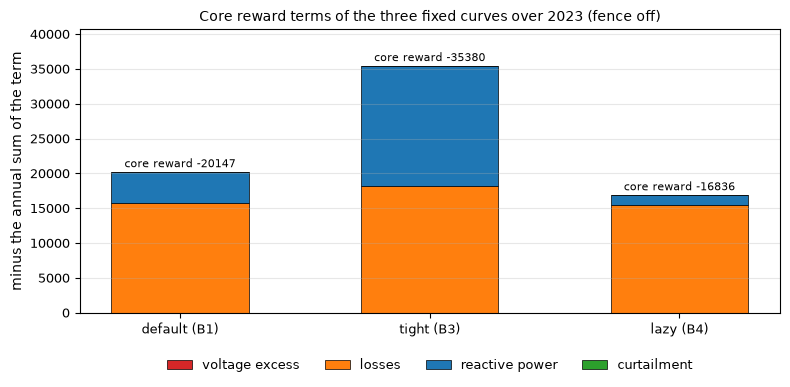

In [9]:
TERMS = [("viol", "voltage excess", "tab:red"), ("loss", "losses", "tab:orange"), ("q", "reactive power", "tab:blue"), ("curt", "curtailment", "tab:green")]
rank = {}
for name in FIXED_ACTIONS:
    t = env.reward_totals(runs[f"{name}_off"]); k = kpi.kpis_of(runs[f"{name}_off"])
    rank[name] = dict(core=t["core"], viol=t["viol"], loss=t["loss"], q=t["q"], curt=t["curt"],
                      hours_violation=k["hours_violation"], q_abs_mvarh=k["reactive_absorbed_mvarh"], losses_mwh=k["losses_mwh"], vmax=k["vmax"])
tab8 = pd.DataFrame(rank).T
print("annual core reward and its terms (fence off), with the KPIs behind them:")
print(tab8.to_string(float_format=lambda x: f"{x:.1f}", formatters={"vmax": "{:.4f}".format}))
order = sorted(FIXED_ACTIONS, key=lambda n: -rank[n]["core"])
print("ranking by core reward: " + " > ".join(f"{n} ({rank[n]['core']:.0f})" for n in order))
assert rank["default"]["core"] > rank["tight"]["core"], "default should beat tight"
assert rank["lazy"]["core"] > rank["default"]["core"], "lazy should beat default"

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(FIXED_ACTIONS)); bottom = np.zeros(len(x))
for key, lab, col in TERMS:
    vals = np.array([-rank[n][key] for n in FIXED_ACTIONS])
    ax.bar(x, vals, 0.55, bottom=bottom, color=col, edgecolor="black", lw=0.5, label=lab)
    bottom += vals
for xi, n in zip(x, FIXED_ACTIONS):
    ax.text(xi, bottom[xi] + 0.01 * bottom.max(), f"core reward {rank[n]['core']:.0f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"{n} ({FIXED_ACTIONS[n][1]})" for n in FIXED_ACTIONS])
ax.set_ylim(0, bottom.max() * 1.15); ax.set_ylabel("minus the annual sum of the term"); ax.grid(axis="y", alpha=0.3)
ax.set_title(f"Core reward terms of the three fixed curves over {YEAR} (fence off)")
legend_below(ax, ncol=4, dy=-0.12)
plt.tight_layout(); plt.show()

The ranking is sensible. The default beats the tight curve by a wide margin, entirely
through the reactive term (four times the absorption) and the loss term (15 % more
losses), which is the notebook-04 finding expressed as a reward. The lazy curve ranks
above the default: it also leaves zero violation hours (annual maximum 1.0485 pu) but
absorbs about a quarter of the reactive energy and has lower losses, so the reward
rightly prefers it. Nothing is curtailed and the violation term is zero for all three, so
the whole ranking is decided by effort and losses. That is the direction in which learning
should move: towards curves that absorb only when the limit is near, which is what the OPF
of notebook 04 does.

## 9. Robustness of the default curve to the PV size

`pv_scale` multiplies Pmpp and kVA of every unit. For each scale in {1.0, 1.25, 1.5, 2.0}
the environment runs the year at unity power factor (no curve, B0) and with the default
action (fence off); the table lists the violation hours, the maximum voltage, the absorbed
reactive energy and the losses. The figure shows (a) the violation hours against the scale
for both, and (b) the annual maximum voltage against the scale with the 1.05 pu line.

unity pf at pv_scale 1.0          : 35040 steps in   12.0 s (0.34 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


unity pf at pv_scale 1.25         : 35040 steps in   12.0 s (0.34 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


default curve at pv_scale 1.25    : 35040 steps in   21.2 s (0.60 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


unity pf at pv_scale 1.5          : 35040 steps in   12.0 s (0.34 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


default curve at pv_scale 1.5     : 35040 steps in   21.7 s (0.62 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


unity pf at pv_scale 2.0          : 35040 steps in   12.0 s (0.34 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


default curve at pv_scale 2.0     : 35040 steps in   22.7 s (0.65 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0
                        pv_mw  hours_violation   vpi  vmax  q_absorbed_mvarh  losses_mwh  curtailed_mwh
pv_scale controller                                                                                    
1.00     unity pf        6.44            199.8 3.995 1.064         4.412e-07       383.7      4.003e-07
         default curve   6.44                0     0 1.042              1040       395.5      7.591e-06
1.25     unity pf        8.05            557.2 38.05 1.076         4.849e-07       437.5      4.367e-07
         default curve   8.05                0     0 1.045              1521       462.4      1.131e-05
1.50     unity pf        9.66            786.2 94.45 1.087          4.76e-07       521.9      4.987e-07
         default curve   9.66                0     0 1.047              2060       566.8      1.531e-05
2.00     unity pf       

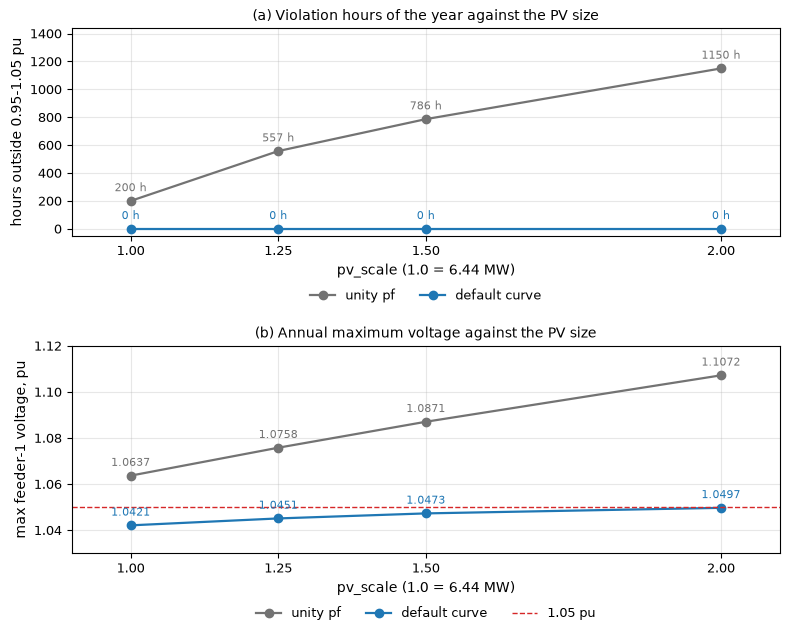

pv_scale 1.00: unity pf  199.75 h, Vmax 1.0637; default curve  0.00 h, Vmax 1.0421,   1040 Mvarh absorbed, losses 396 MWh
pv_scale 1.25: unity pf  557.25 h, Vmax 1.0758; default curve  0.00 h, Vmax 1.0451,   1521 Mvarh absorbed, losses 462 MWh
pv_scale 1.50: unity pf  786.25 h, Vmax 1.0871; default curve  0.00 h, Vmax 1.0473,   2060 Mvarh absorbed, losses 567 MWh
pv_scale 2.00: unity pf 1149.75 h, Vmax 1.1072; default curve  0.00 h, Vmax 1.0497,   3240 Mvarh absorbed, losses 886 MWh


In [10]:
SCALES = [1.0, 1.25, 1.5, 2.0]
sweep = {}
for s in SCALES:
    for lab, pol in (("unity pf", None), ("default curve", env.constant_policy(DEFAULT_ACTION))):
        key = f"sweep_{'B0' if pol is None else 'B1'}_{s}"
        if s == 1.0 and pol is not None:
            rs = runs["default_off"]
        else:
            rs = VoltVarEnv(EnvConfig(pv_scale=s, safety_layer=False), pv, loads).run_policy(pol, None, label=f"{lab} at pv_scale {s}")
            runs[key] = rs; runtime[key] = rs.runtime_s
        sweep[(s, lab)] = kpi.kpis_of(rs)
rows = []
for s in SCALES:
    for lab in ("unity pf", "default curve"):
        k = sweep[(s, lab)]
        rows.append(dict(pv_scale=s, controller=lab, pv_mw=PV_KW.sum() * s / 1e3, hours_violation=k["hours_violation"], vpi=k["vpi"],
                         vmax=k["vmax"], q_absorbed_mvarh=k["reactive_absorbed_mvarh"], losses_mwh=k["losses_mwh"], curtailed_mwh=k["curtailed_mwh"]))
tab9 = pd.DataFrame(rows).set_index(["pv_scale", "controller"])
print(tab9.to_string(float_format=lambda x: f"{x:.4g}"))

fig, axes = plt.subplots(2, 1, figsize=(8, 6.5))
ax = axes[0]
for lab, col in (("unity pf", "0.45"), ("default curve", "tab:blue")):
    hv = [sweep[(s, lab)]["hours_violation"] for s in SCALES]
    ax.plot(SCALES, hv, "o-", color=col, lw=1.6, label=lab)
    for s, v in zip(SCALES, hv):
        ax.annotate(f"{v:.0f} h", (s, v), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color=col)
ax.set_xlim(0.9, 2.1); ax.set_ylim(-50, max(sweep[(s, "unity pf")]["hours_violation"] for s in SCALES) * 1.25); ax.grid(alpha=0.3)
ax.set_xticks(SCALES); ax.set_xlabel("pv_scale (1.0 = 6.44 MW)"); ax.set_ylabel("hours outside 0.95-1.05 pu")
ax.set_title(f"(a) Violation hours of the year against the PV size")
legend_below(ax, ncol=2, dy=-0.2)
ax = axes[1]
for lab, col in (("unity pf", "0.45"), ("default curve", "tab:blue")):
    vm = [sweep[(s, lab)]["vmax"] for s in SCALES]
    ax.plot(SCALES, vm, "o-", color=col, lw=1.6, label=lab)
    for s, v in zip(SCALES, vm):
        ax.annotate(f"{v:.4f}", (s, v), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color=col)
ax.axhline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu")
ax.set_xlim(0.9, 2.1); ax.set_ylim(1.03, 1.12); ax.grid(alpha=0.3)
ax.set_xticks(SCALES); ax.set_xlabel("pv_scale (1.0 = 6.44 MW)"); ax.set_ylabel("max feeder-1 voltage, pu")
ax.set_title("(b) Annual maximum voltage against the PV size")
legend_below(ax, ncol=3, dy=-0.2)
plt.tight_layout(); plt.show()
for s in SCALES:
    k0, k1 = sweep[(s, "unity pf")], sweep[(s, "default curve")]
    print(f"pv_scale {s:4.2f}: unity pf {k0['hours_violation']:7.2f} h, Vmax {k0['vmax']:.4f}; default curve {k1['hours_violation']:5.2f} h, "
          f"Vmax {k1['vmax']:.4f}, {k1['reactive_absorbed_mvarh']:6.0f} Mvarh absorbed, losses {k1['losses_mwh']:.0f} MWh")

The violation hours at unity power factor grow steadily with the PV size, from 200 h to
well over a thousand at twice the PV, but the default curve removes all of them at every
scale, and its annual maximum settles just below 1.05 pu. This is a property of the
standard's parameterisation: Q is a fraction of the inverter kVA, and kVA scales with
Pmpp, so the absorption available at a given terminal voltage grows in proportion to the
active power that causes the voltage rise. At 1.05 pu the default curve draws 0.22 pu of
kVA, at 1.08 pu 0.44 pu; the voltage rise per kW of PV and the voltage drop per kvar are of
the same order on these cables, so the closed loop of curve and feeder has a fixed point
near 1.05 pu at any scale. The default curve is self-limiting on this feeder; what grows
with the PV size is its cost, which triples between 1.0 and 2.0 in reactive energy and
more than doubles in losses.

For the study this means that the target at 100 % PV is not fewer violations, since the
default curve already has none, but the same zero violations with less reactive effort
and lower losses, which is what the lazy curve of step 8 already shows to be possible and
what the next notebook trains for.

## 10. Save

`env_config.json` holds the `EnvConfig` used for training (all defaults, safety layer
on), the curve parameterisation with its ranges and the three fixed actions, the names of
the observations and actions, the consistency KPIs, the reward ranking and the PV-scale
sweep. `env_checks_2023.h5` holds every run of this notebook (one group per run: the step
indices, the voltages of buses 1 to 11 after the fence and before it, P and Q of the nine
units, irradiance, losses, the reward, the core reward and the five terms, the safety
flags and amounts, the curves applied, the KPIs and the configuration as attributes).

In [11]:
cfg_train = EnvConfig(safety_layer=True, seed=0, label="100 % PV, fence on: hold the limit with less reactive effort and loss than the default curve")
config = dict(env=cfg_train.__dict__,
              curve=dict(fixed=dict(V1=env.V1, Q1=env.Q1, V2=env.V2), V3_range=list(env.V3_RANGE), V4_range=[f"V3 + {env.V4_GAP}", env.V4_MAX],
                         Q4_range=list(env.Q4_RANGE), default_action=DEFAULT_ACTION.tolist(), tight_action=TIGHT_ACTION.tolist(),
                         lazy_action=LAZY_ACTION.tolist(), default_curve=action_to_curve(DEFAULT_ACTION).tolist(),
                         tight_curve=action_to_curve(TIGHT_ACTION).tolist(), lazy_curve=action_to_curve(LAZY_ACTION).tolist()),
              obs_names=env.OBS_NAMES, act_names=env.ACT_NAMES, n_units=env.N_UNITS, pv_buses=PV_BUSES, f1_buses=F1,
              consistency={n: dict(env=kpi.kpis_of(runs[f"{n}_off"]), reference=ref, reference_kpis=K04[ref]) for n, (a, ref) in FIXED_ACTIONS.items()},
              reward_ranking=rank, fence_random_worst_day=dict(off=safety_stats(r_off), on=safety_stats(r_on)),
              fence_random_year=st7, pv_scale_sweep={f"{s}_{lab.replace(' ', '_')}": sweep[(s, lab)] for s in SCALES for lab in ("unity pf", "default curve")},
              runtime_s=runtime)
with open("env_config.json", "w") as f:
    json.dump(config, f, indent=2, default=float)
with h5py.File("env_checks_2023.h5", "w") as f:
    f.attrs["year"] = attrs["year"]; f.attrs["dt_h"] = DT_H; f.attrs["pv_buses"] = PV_BUSES; f.attrs["f1_buses"] = F1
    f.attrs["tr1_tap_pct"] = TR1_TAP; f.attrs["kva_ratio"] = sim.KVA_RATIO
    for name, r in runs.items():
        g = f.create_group(name)
        g.attrs["label"] = r.label; g.attrs["config"] = json.dumps(r.extra["config"]); g.attrs["runtime_s"] = r.runtime_s; g.attrs["pv_kw"] = r.pv_kw
        g.create_dataset("steps", data=r.steps); g.create_dataset("time", data=(r.index.asi8 // 10 ** 9).astype(np.int64))
        for k in ("v", "p_kw", "q_kvar", "irr", "losses_kw"):
            g.create_dataset(k, data=getattr(r, k).astype(np.float32), compression="gzip")
        g.create_dataset("failed", data=r.failed)
        for k in ("reward", "reward_core", "term_viol", "term_loss", "term_q", "term_curt", "term_safety", "safety_dq", "safety_dp", "v_before", "curves"):
            g.create_dataset(k, data=r.extra[k].astype(np.float32), compression="gzip")
        g.create_dataset("safety_active", data=r.extra["safety_active"]); g.create_dataset("safety_solves", data=r.extra["safety_solves"])
        g["v"].attrs["description"] = "voltage of buses 1..11 (columns), pu of 20 kV, after the safety layer"
        g["v_before"].attrs["description"] = "voltage of buses 1..11 before the safety layer"
        g["curves"].attrs["description"] = "(step, unit, [V3, V4, Q4]) applied; NaN for unity-pf runs"
        for k, v in kpi.kpis_of(r).items():
            g.attrs["kpi_" + k] = v
    f.attrs["pv_scale_sweep_json"] = tab9.reset_index().to_json(orient="records")
    f.attrs["reward_ranking_json"] = tab8.reset_index().to_json(orient="records")
with h5py.File("env_checks_2023.h5", "r") as f:
    print("env_checks_2023.h5:", len(f.keys()), "run groups:", ", ".join(sorted(f.keys())))
    print("datasets per group:", list(f["random_year_on"]))
print("env_config.json: env =", json.dumps({k: cfg_train.__dict__[k] for k in ("pv_scale", "kva_ratio", "tr1_tap_pct", "safety_layer", "w_viol", "w_loss", "w_q", "w_curt", "w_safety", "w_safety_event")}))
print(f"full-year passes of this notebook: {len(runtime)} runs, {sum(runtime.values()):.0f} s in total (mean {np.mean(list(runtime.values())):.1f} s per pass)")

env_checks_2023.h5: 13 run groups: default_off, lazy_off, random_worst_off, random_worst_on, random_year_on, sweep_B0_1.0, sweep_B0_1.25, sweep_B0_1.5, sweep_B0_2.0, sweep_B1_1.25, sweep_B1_1.5, sweep_B1_2.0, tight_off
datasets per group: ['curves', 'failed', 'irr', 'losses_kw', 'p_kw', 'q_kvar', 'reward', 'reward_core', 'safety_active', 'safety_dp', 'safety_dq', 'safety_solves', 'steps', 'term_curt', 'term_loss', 'term_q', 'term_safety', 'term_viol', 'time', 'v', 'v_before']
env_config.json: env = {"pv_scale": 1.0, "kva_ratio": 1.1, "tr1_tap_pct": 4.375, "safety_layer": true, "w_viol": 1000.0, "w_loss": 0.01, "w_q": 0.001, "w_curt": 0.05, "w_safety": 0.002, "w_safety_event": 5.0}
full-year passes of this notebook: 11 runs, 198 s in total (mean 18.0 s per pass)


## 11. Closing

- **What is fixed.** The feeder, the nine units and their ratings (kVA = 1.1 Pmpp), the
  TR1 tap at +4.375 %, the year of profiles, the KPIs, and the lower half of every curve
  (V1 = 0.92, Q1 = +0.44, V2 = 0.98): undervoltage does not occur on this feeder, so it is
  not learned. The environment reproduces B1, B3 and B4 of notebook 04 to within the
  control tolerance when given the corresponding fixed actions (step 5), so the baselines
  of notebook 04 remain valid references.
- **What the agent controls.** Per unit and per 15-minute step, three numbers: where
  absorption starts (V3 in [1.00, 1.03]), where it reaches its clamp (V4 in
  [V3 + 0.02, 1.18]) and how deep the clamp is (Q4 in [0, 0.44] of kVA), from a local
  observation of its own voltage, P, Q, the time of day and the irradiance. Every
  reachable curve is inside the allowable ranges of IEEE 1547-2018 Table 8. The reward is
  shared: the voltage excess of feeder 1, the losses, the reactive power of all units and
  the curtailment, weighted 1000 per pu, 0.01 per kW, 0.001 per kvar and 0.05 per kW,
  plus the fence charge (0.002 per kvar the fence adds, ten times that per kW it curtails,
  and 5 per intervention). The ranking of step 8 shows that the core weights order a
  wasteful holding curve below an economical one.
- **What the fence guarantees.** With the safety layer on, no step ends outside 0.95 to
  1.05 pu as long as the units have reactive or active power to give: on a violated step
  it measures the sensitivities on the actual circuit, adds the least-squares absorption
  that brings every bus to 1.048 pu, and curtails only if the reactive capability is
  exhausted (never needed in this notebook). Under a random policy it acted on a few tens
  of steps in the year and left zero violation hours (step 7). The agent's action is a
  proposal; the fence's correction appears in the reward and in `info`, so the agent can
  learn to avoid it.
- **The target for training.** At 100 % PV the default curve already holds the limit, and
  it holds it at any PV size because its absorption scales with the inverter kVA (step 9).
  The target is therefore the same zero violations with less reactive effort and lower
  losses: the lazy curve (core reward about -16,800 against -20,100 for the default over
  the year) shows that this is possible with one fixed curve, and the OPF of notebook 04
  shows how far a per-unit, per-step choice could go. The next notebook trains local
  agents in this environment against those references.

Files: `env.py` (`EnvConfig`, `VoltVarEnv`, `action_to_curve`, `curve_to_action`,
`DEFAULT_ACTION`, `TIGHT_ACTION`, `LAZY_ACTION`, `run_policy`, `EnvYearResult`,
`reward_totals`, `reward_core_of`), `env_config.json`, `env_checks_2023.h5` and this
notebook. `cigre_dss.py`, `profiles.py`, `simulate.py` and `kpi.py` are unchanged.